In [7]:
from matrix import*  
from solver import Newmarksuper_HSI2,accdyn_super 
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3
#ped
numped = 5
pedmass = 70     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped1=(2*np.pi*pedBodyF)**2*pedmass
cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass

#mat=np.zeros(1,numped) #to be extended into probabilistic inputs
mped=np.array([pedmass,pedmass,pedmass,pedmass,pedmass])
cped = np.array([cped1,cped1,cped1,cped1,cped1])
kped = np.array([kped1,kped1,kped1,kped1,kped1])

#bridge
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0,-5,-10,-15,-20]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


In [8]:
u,du,ddu_hsi = Newmarksuper_HSI2(Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,kped,cped,xrb,linearMass)
                
accn_hsi = accdyn_super(Bridge,ddu_hsi,x_interested,hht)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


[[ 0.00000000e+00  7.59910994e-03  1.49506805e-02 ... -7.26781671e+01
  -4.60474409e+01  0.00000000e+00]
 [ 0.00000000e+00  1.43267986e-02  2.49656911e-02 ... -9.18275281e+00
  -4.23055723e+00  0.00000000e+00]
 [ 0.00000000e+00  1.72133652e-02  1.73327240e-02 ... -1.76426745e-02
  -4.93347319e-03  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -2.08433550e+00
  -2.00368875e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -2.95308055e+00
  -2.84431180e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -3.53578663e+00
  -3.41145981e+00  0.00000000e+00]]


In [9]:
u,du,ddu = Newmarksuper_HSI2(Human,Bridge,numped,numbers,length,hht,pedvelocity,mped,[0,0,0,0,0],[0,0,0,0,0],xrb,linearMass)
                
accn = accdyn_super(Bridge,ddu,x_interested,hht)


[[ 0.00000000e+00  7.59910996e-03  1.49506807e-02 ... -4.08243580e+01
   6.23781182e+01  0.00000000e+00]
 [ 0.00000000e+00  1.43267986e-02  2.49656914e-02 ... -9.92715081e+00
  -5.15848857e+00  0.00000000e+00]
 [ 0.00000000e+00  1.72133652e-02  1.73327243e-02 ...  1.32865246e-03
   1.18299905e-02  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


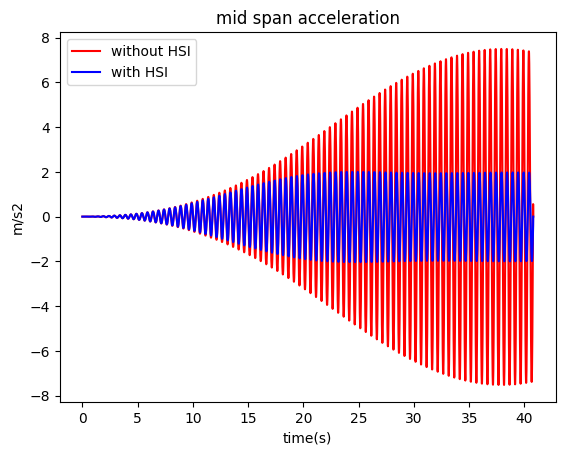

In [10]:
t = np.arange(0, (length+1) / pedvelocity, hht)
plt.plot(t,accn , label ="without HSI" ,color='r')
plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
#plt.plot(t,vertical_displacement)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)

In [6]:
# Find the index of the maximum value in accn and accn_hsi
max_index_accn = np.argmax(accn)
max_index_accn_hsi = np.argmax(accn_hsi)

# Find the maximum values
max_accn = accn[max_index_accn]
max_accn_hsi = accn_hsi[max_index_accn_hsi]

# Find the corresponding times
max_time_accn = t[max_index_accn]
max_time_accn_hsi = t[max_index_accn_hsi]

# Print the results
print(f"Maximum acceleration without HSI: {max_accn} m/s² at time {max_time_accn} s")
print(f"Maximum acceleration with HSI: {max_accn_hsi} m/s² at time {max_time_accn_hsi} s")

Maximum acceleration without HSI: 8.113249585556696 m/s² at time 31.900000000000002 s
Maximum acceleration with HSI: 2.2079794830546824 m/s² at time 37.92 s
